# Notebook 04b — Fine-tuning Multilingue Étendu (20 langues)
**Projet :** Système Intelligent de Détection de Spam et de Phishing  
**Auteur :** Nghogué Taptué Franck Roddier — 5GI, ENSPY  
**Modèle :** `distilbert-base-multilingual-cased` (mBERT — 104 langues)

---

## Stratégie

mBERT comprend 104 langues **au niveau de la tokenisation** grâce à son pré-entraînement sur Wikipédia multilingue. Pour que le **classifieur** (la tête de classification) détecte correctement spam/phishing dans toutes les langues, il faut lui fournir des exemples dans ces langues.

**Solution :** traduction automatique du corpus anglais vers 20 langues via Google Translate.

```
Corpus anglais (emails_features.csv)
           ↓  × 20 langues
  Traduction automatique (GoogleTranslator)
           ↓
  Corpus multilingue (~20× plus grand)
           ↓
  Fine-tuning mBERT
           ↓
  Évaluation par langue + transfert zero-shot
```

## 20 langues couvertes

| Groupe | Langues |
|--------|---------|
| **Romanes** | Français · Espagnol · Portugais · Italien |
| **Germaniques** | Allemand · Néerlandais · Suédois |
| **Slaves** | Russe · Polonais |
| **Asie de l'Est** | Chinois simplifié · Japonais · Coréen · Vietnamien · Thaï · Indonésien · Malais |
| **Moyen-Orient/Asie du Sud** | Arabe · Hindi · Persan · Turc |

> **Note sur le temps d'exécution :** La traduction de l'ensemble du corpus prend du temps.
> Le notebook propose un mode `FAST_MODE` qui traduit un sous-ensemble représentatif
> (50 emails/langue) pour valider la démarche rapidement sur Colab T4.

In [1]:
!pip install transformers torch scikit-learn pandas numpy matplotlib \
             seaborn joblib tqdm deep-translator langdetect

In [2]:
import os
from pathlib import Path
from google.colab import drive

# 1. Monter le drive
drive.mount('/content/drive')

# 2. Se déplacer dans le dossier du projet
# Remplace par le chemin exact de ton dossier
os.chdir('/content/drive/MyDrive/notebooks')

# 3. Vérifier que le dossier 'data' est bien là
DATA_DIR = Path('data')
if DATA_DIR.exists():
    print("Dossier data trouvé !")
else:
    print("Dossier data introuvable. Contenu actuel :", os.listdir())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dossier data trouvé !


In [3]:
import json, warnings, joblib, time as time_module
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from collections import defaultdict

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from sklearn.metrics import (
    classification_report, f1_score, accuracy_score
)
from sklearn.model_selection import train_test_split
from deep_translator import GoogleTranslator

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 5)
sns.set_style('whitegrid')

DATA_DIR  = Path('data')
MODEL_DIR = DATA_DIR / 'multilingual_model'
MODEL_DIR.mkdir(exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')

MULTILINGUAL_MODEL = 'distilbert-base-multilingual-cased'
print(f'Modèle : {MULTILINGUAL_MODEL}')

Device : cuda
GPU    : Tesla T4
Modèle : distilbert-base-multilingual-cased


## 1. Configuration des langues

In [4]:
# ── 20 langues cibles ────────────────────────────────────────────
# Format : (code_google_translate, nom_affichage, groupe_linguistique)
TARGET_LANGUAGES = [
    # Romanes
    ('french',               'Français',   'Roman'),
    ('spanish',              'Espagnol',   'Roman'),
    ('portuguese',           'Portugais',  'Roman'),
    ('italian',              'Italien',    'Roman'),
    # Germaniques
    ('german',               'Allemand',   'Germanic'),
    ('dutch',                'Néerlandais','Germanic'),
    ('swedish',              'Suédois',    'Germanic'),
    # Slaves
    ('russian',              'Russe',      'Slavic'),
    ('polish',               'Polonais',   'Slavic'),
    # Asie de l'Est / Asie du Sud-Est
    ('chinese (simplified)', 'Chinois',    'East Asian'),
    ('japanese',             'Japonais',   'East Asian'),
    ('korean',               'Coréen',     'East Asian'),
    ('vietnamese',           'Vietnamien', 'SEA'),
    ('thai',                 'Thaï',       'SEA'),
    ('indonesian',           'Indonésien', 'SEA'),
    ('malay',                'Malais',     'SEA'),
    # Moyen-Orient / Asie du Sud
    ('arabic',               'Arabe',      'MENA'),
    ('hindi',                'Hindi',      'South Asian'),
    ('persian',              'Persan',     'MENA'),
    ('turkish',              'Turc',       'Turkic'),
]

# ── Paramètres de traduction ────────────────────────────────────
# FAST_MODE = True  → 50 emails/langue (démonstration rapide, ~15 min)
# FAST_MODE = False → 200 emails/langue (entraînement complet, ~60 min)
FAST_MODE         = True
N_PER_CLASS_LANG  = 50 if FAST_MODE else 200   # emails par classe ET par langue
SLEEP_BETWEEN_REQ = 0.4                         # secondes entre requêtes (limite API)

print(f'Langues cibles    : {len(TARGET_LANGUAGES)}')
print(f'Mode              : {"FAST (50/classe/langue)" if FAST_MODE else "FULL (200/classe/langue)"}')
print(f'Emails à traduire : ~{len(TARGET_LANGUAGES) * 3 * N_PER_CLASS_LANG:,}')
print(f'Temps estimé      : ~{len(TARGET_LANGUAGES) * 3 * N_PER_CLASS_LANG * SLEEP_BETWEEN_REQ / 60:.0f} min')

Langues cibles    : 20
Mode              : FAST (50/classe/langue)
Emails à traduire : ~3,000
Temps estimé      : ~20 min


## 2. Traduction automatique multilingue

Le corpus anglais est traduit vers les 20 langues. Les traductions sont sauvegardées
dans `data/emails_multilingual.csv` pour éviter de retélécharger à chaque exécution.

In [5]:
MULTILANG_PATH = DATA_DIR / 'emails_multilingual.csv'

def translate_batch(texts, target_lang, sleep=0.4):
    """
    Traduit une liste de textes vers la langue cible.
    Retourne les textes traduits (None si erreur).
    """
    translator = GoogleTranslator(source='en', target=target_lang)
    results    = []
    for text in texts:
        try:
            translated = translator.translate(str(text)[:4500])
            results.append(translated)
        except Exception:
            results.append(None)  # On garde None pour filtrer ensuite
        time_module.sleep(sleep)
    return results


if MULTILANG_PATH.exists():
    # Chargement des traductions déjà faites
    df_multilang = pd.read_csv(MULTILANG_PATH)
    already_done = set(df_multilang['lang_code'].unique())
    langs_todo   = [(c,n,g) for c,n,g in TARGET_LANGUAGES if c not in already_done]
    print(f'Traductions existantes chargées : {len(df_multilang):,} emails')
    print(f'Langues déjà traduites : {len(already_done)}')
    print(f'Langues restantes      : {len(langs_todo)}')
else:
    df_multilang = pd.DataFrame()
    langs_todo   = TARGET_LANGUAGES
    print(f'Aucune traduction existante. Démarrage de zéro.')
    print(f'{len(langs_todo)} langues à traduire.')

Traductions existantes chargées : 1,200 emails
Langues déjà traduites : 20
Langues restantes      : 0


In [6]:
# Chargement du corpus anglais source
df_en = pd.read_csv(DATA_DIR / 'emails_features.csv')[['text','label']]
df_en['lang_code'] = 'english'
df_en['lang_name'] = 'Anglais'
df_en['lang_group']= 'Germanic'

print(f'Corpus anglais source : {len(df_en):,} emails')
print(df_en['label'].value_counts())

Corpus anglais source : 22,246 emails
label
ham         13876
phishing     6973
spam         1397
Name: count, dtype: int64


In [7]:
# ── Traduction vers les langues restantes ────────────────────────
# Ce bloc peut prendre du temps — les résultats sont sauvegardés
# progressivement pour ne pas perdre le travail en cas d'erreur.

new_records = []

for lang_code, lang_name, lang_group in langs_todo:
    print(f'\nTraduction → {lang_name} ({lang_code})...')
    lang_records = []

    for label in ['ham', 'spam', 'phishing']:
        subset = df_en[df_en['label'] == label].sample(
            min(N_PER_CLASS_LANG, len(df_en[df_en['label'] == label])),
            random_state=42
        )

        texts_to_translate = subset['text'].tolist()
        translated_texts   = translate_batch(texts_to_translate, lang_code, SLEEP_BETWEEN_REQ)

        for original, translated in zip(texts_to_translate, translated_texts):
            if translated:   # Filtre les erreurs
                lang_records.append({
                    'text':       translated,
                    'label':      label,
                    'lang_code':  lang_code,
                    'lang_name':  lang_name,
                    'lang_group': lang_group,
                })

        ok = sum(1 for t in translated_texts if t)
        print(f'  {label:10s} : {ok}/{len(texts_to_translate)} traduits')

    new_records.extend(lang_records)

    # Sauvegarde incrémentale après chaque langue
    if new_records:
        df_new = pd.DataFrame(new_records)
        df_multilang = pd.concat([df_multilang, df_new], ignore_index=True) if len(df_multilang) > 0 else df_new
        df_multilang.to_csv(MULTILANG_PATH, index=False)
        new_records = []
        print(f'  Sauvegardé : {len(df_multilang):,} emails au total')

print(f'\nTraduction terminée : {len(df_multilang):,} emails multilingues')


Traduction terminée : 1,200 emails multilingues


## 3. Construction du dataset final

In [8]:
# Fusion anglais + toutes les langues traduites
label_encoder = joblib.load(DATA_DIR / 'label_encoder.pkl')
CLASS_NAMES   = list(label_encoder.classes_)
N_CLASSES     = len(CLASS_NAMES)
LABEL2ID      = {c: i for i, c in enumerate(CLASS_NAMES)}

# Normalisation du DataFrame anglais pour la fusion
df_en_norm = df_en.rename(columns={'lang_code':'lang_code'}).copy()
if 'lang_name'  not in df_en_norm.columns: df_en_norm['lang_name']  = 'Anglais'
if 'lang_group' not in df_en_norm.columns: df_en_norm['lang_group'] = 'Germanic'

# Fusion
df_all = pd.concat([df_en_norm, df_multilang], ignore_index=True)
df_all = df_all.dropna(subset=['text','label']).reset_index(drop=True)
df_all['label_id'] = df_all['label'].map(LABEL2ID)
df_all = df_all.dropna(subset=['label_id']).reset_index(drop=True)
df_all['label_id'] = df_all['label_id'].astype(int)
df_all = df_all.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Dataset multilingue final : {len(df_all):,} emails')
print(f'\nPar langue (top 10) :')
print(df_all['lang_name'].value_counts().head(10))
print(f'\nPar classe :')
print(df_all['label'].value_counts())

Dataset multilingue final : 23,446 emails

Par langue (top 10) :
lang_name
Anglais        22246
Thaï              60
Polonais          60
Russe             60
Arabe             60
Malais            60
Néerlandais       60
Chinois           60
Coréen            60
Italien           60
Name: count, dtype: int64

Par classe :
label
ham         14276
phishing     7373
spam         1797
Name: count, dtype: int64


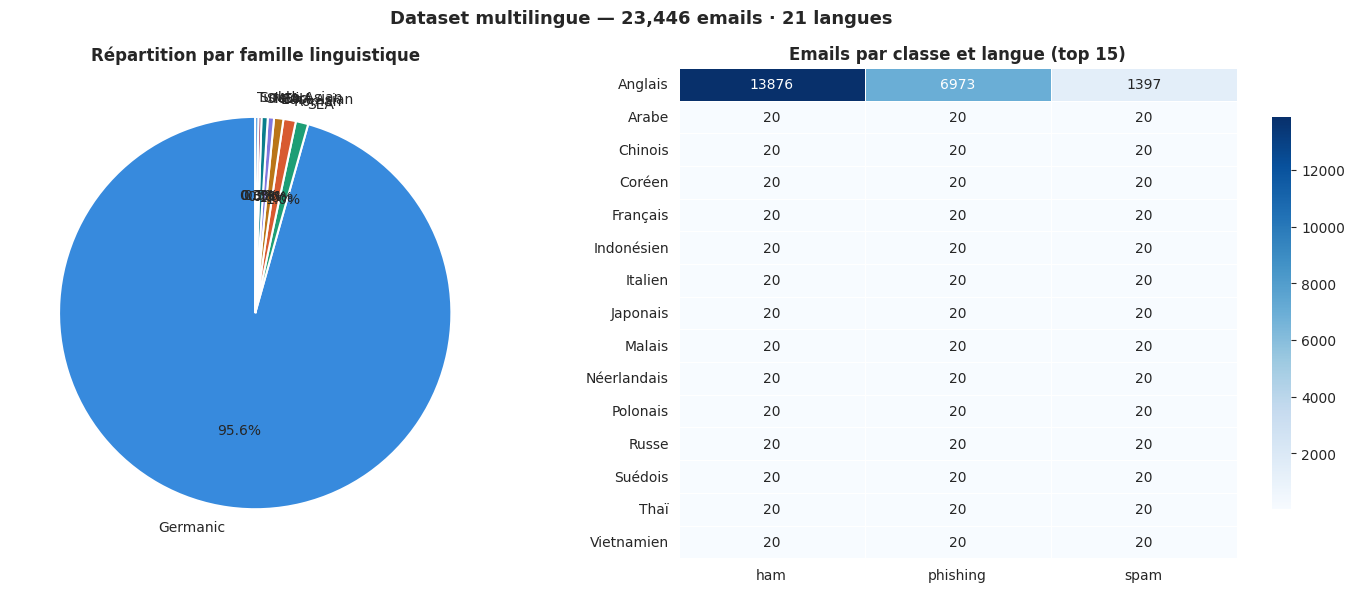

In [9]:
# ── Visualisation composition du dataset ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Par groupe linguistique
group_counts = df_all['lang_group'].value_counts()
colors_group = ['#378ADD','#1D9E75','#D85A30','#BA7517','#7F77DD',
                '#0A7E8C','#993556']
axes[0].pie(group_counts.values, labels=group_counts.index,
            colors=colors_group[:len(group_counts)],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[0].set_title('Répartition par famille linguistique', fontweight='bold')

# Heatmap : classe × langue (top 15 langues)
top_langs = df_all['lang_name'].value_counts().head(15).index
pivot = df_all[df_all['lang_name'].isin(top_langs)].groupby(
    ['lang_name','label']).size().unstack(fill_value=0)
sns.heatmap(pivot, ax=axes[1], cmap='Blues', annot=True, fmt='d',
            linewidths=0.5, cbar_kws={'shrink':0.8})
axes[1].set_title('Emails par classe et langue (top 15)', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('')

plt.suptitle(f'Dataset multilingue — {len(df_all):,} emails · {df_all["lang_name"].nunique()} langues',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('data/04b_dataset_composition.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Tokenisation & splits

In [10]:
print(f'Chargement du tokeniseur multilingue...')
tokenizer = AutoTokenizer.from_pretrained(MULTILINGUAL_MODEL)
print(f'Vocabulaire : {tokenizer.vocab_size:,} tokens (vs 30 522 pour distilbert-en)')

# Démonstration : même phrase de phishing en 5 langues
phrase = "Your account has been suspended. Verify immediately."
translations = [
    ('EN', phrase),
    ('FR', 'Votre compte a été suspendu. Vérifiez immédiatement.'),
    ('AR', 'تم تعليق حسابك. تحقق على الفور.'),
    ('ZH', '您的账户已被暂停。请立即验证。'),
    ('HI', 'आपका खाता निलंबित कर दिया गया है। तुरंत सत्यापित करें।'),
]
print('\nTokenisation multilingue (même phrase, 5 langues) :')
for lang, text in translations:
    tokens = tokenizer.tokenize(text)
    print(f'  [{lang}] {len(tokens):2d} tokens : {tokens[:8]}...' if len(tokens)>8 else f'  [{lang}] {len(tokens):2d} tokens : {tokens}')

Chargement du tokeniseur multilingue...


Vocabulaire : 119,547 tokens (vs 30 522 pour distilbert-en)

Tokenisation multilingue (même phrase, 5 langues) :
  [EN] 10 tokens : ['Your', 'account', 'has', 'been', 'suspended', '.', 'Ver', '##ify']...
  [FR] 15 tokens : ['Vo', '##tre', 'compte', 'a', 'été', 'sus', '##pend', '##u']...
  [AR] 14 tokens : ['تم', 'ت', '##عل', '##يق', 'حساب', '##ك', '.', 'ت']...
  [ZH] 15 tokens : ['您', '的', '账', '户', '已', '被', '暂', '停']...
  [HI] 24 tokens : ['आ', '##प', '##का', 'खाता', 'न', '##िल', '##ं', '##ब']...


In [11]:
MAX_LENGTH = 256
BATCH_SIZE = 16 if DEVICE.type == 'cuda' else 8

class MultilingualEmailDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts     = [str(t)[:3000] for t in texts]
        self.labels    = list(labels)
        self.tokenizer = tokenizer
        self.max_len   = max_length

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx], max_length=self.max_len,
            padding='max_length', truncation=True, return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }


# Split stratifié sur la classe (pas la langue — on veut toutes les langues dans le test)
df_train_val, df_test = train_test_split(
    df_all, test_size=0.15, random_state=42, stratify=df_all['label_id']
)
df_train, df_val = train_test_split(
    df_train_val, test_size=0.15, random_state=42, stratify=df_train_val['label_id']
)

train_ds = MultilingualEmailDataset(df_train['text'], df_train['label_id'], tokenizer, MAX_LENGTH)
val_ds   = MultilingualEmailDataset(df_val['text'],   df_val['label_id'],   tokenizer, MAX_LENGTH)
test_ds  = MultilingualEmailDataset(df_test['text'],  df_test['label_id'],  tokenizer, MAX_LENGTH)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train : {len(train_ds):,} | Val : {len(val_ds):,} | Test : {len(test_ds):,}')
print(f'Langues dans le test : {df_test["lang_name"].nunique()}')

Train : 16,939 | Val : 2,990 | Test : 3,517
Langues dans le test : 21


## 5. Fine-tuning mBERT

In [14]:
ID2LABEL = {i: c for i, c in enumerate(CLASS_NAMES)}

print(f'Chargement de {MULTILINGUAL_MODEL}...')
model = AutoModelForSequenceClassification.from_pretrained(
    MULTILINGUAL_MODEL,
    num_labels=N_CLASSES,
    id2label=ID2LABEL,
    label2id=LABEL2ID
).to(DEVICE)

print(f'Paramètres : {sum(p.numel() for p in model.parameters()):,}')

# Class weights
cc = df_train['label_id'].value_counts().sort_index().values
cw = torch.tensor([1.0/c for c in cc], dtype=torch.float32)
cw = (cw / cw.sum() * N_CLASSES).to(DEVICE)
loss_fn = nn.CrossEntropyLoss(weight=cw)

# Optimiseur & scheduler
N_EPOCHS     = 4
LR           = 2e-5
PATIENCE     = 2
total_steps  = len(train_loader) * N_EPOCHS
optimizer    = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
scheduler    = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(total_steps*0.1),
    num_training_steps=total_steps
)
print(f'Steps total : {total_steps} | LR : {LR}')


def run_epoch(model, loader, train=True):
    model.train() if train else model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in tqdm(loader, desc=' Train' if train else '  Eval', leave=False):
            ids  = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)
            lbls = batch['labels'].to(DEVICE)
            out  = model(input_ids=ids, attention_mask=mask)
            loss = loss_fn(out.logits, lbls)
            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()
            total_loss  += loss.item()
            all_preds   .extend(out.logits.argmax(-1).cpu().numpy())
            all_labels  .extend(lbls.cpu().numpy())
    y_true, y_pred = np.array(all_labels), np.array(all_preds)
    return (total_loss/len(loader),
            accuracy_score(y_true, y_pred),
            f1_score(y_true, y_pred, average='macro', zero_division=0),
            y_true, y_pred)


# ── Boucle d'entraînement ────────────────────────────────────────
history = defaultdict(list)
best_f1, patience_ctr, best_epoch = 0.0, 0, 0

print('\nEntraînement multilingue (20 langues)...')
print('=' * 60)

for epoch in range(1, N_EPOCHS + 1):
    print(f'\nÉpoque {epoch}/{N_EPOCHS}')
    tr_loss, tr_acc, tr_f1, *_ = run_epoch(model, train_loader, train=True)
    vl_loss, vl_acc, vl_f1, *_ = run_epoch(model, val_loader, train=False)

    for k, v in [('train_loss',tr_loss),('train_acc',tr_acc),('train_f1',tr_f1),
                 ('val_loss',vl_loss),('val_acc',vl_acc),('val_f1',vl_f1)]:
        history[k].append(v)

    print(f'  Train → loss:{tr_loss:.4f}  F1:{tr_f1:.4f}')
    print(f'  Val   → loss:{vl_loss:.4f}  F1:{vl_f1:.4f}  Acc:{vl_acc:.4f}')

    if vl_f1 > best_f1:
        best_f1, best_epoch, patience_ctr = vl_f1, epoch, 0
        model.save_pretrained(MODEL_DIR)
        tokenizer.save_pretrained(MODEL_DIR)
        print(f'  ✓ Meilleur modèle sauvegardé (F1={best_f1:.4f})')
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f'\nEarly stopping — époque {epoch}.')
            break

print(f'\nEntraînement terminé. Best F1-val : {best_f1:.4f} (époque {best_epoch})')

Chargement de distilbert-base-multilingual-cased...


model.safetensors:   0%|          | 0.00/542M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Paramètres : 135,326,979
Steps total : 4236 | LR : 2e-05

Entraînement multilingue (20 langues)...

Époque 1/4


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Meilleur modèle sauvegardé (F1=0.9843)

Époque 4/4


  Train → loss:0.0066  F1:0.9978
  Val   → loss:0.0767  F1:0.9851  Acc:0.9856


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Meilleur modèle sauvegardé (F1=0.9851)

Entraînement terminé. Best F1-val : 0.9851 (époque 4)


## 6. Évaluation par langue — le cœur de ce notebook

In [15]:
# Rechargement du meilleur modèle
best_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_DIR, num_labels=N_CLASSES
).to(DEVICE)

# Évaluation globale
_, test_acc, test_f1, y_true_all, y_pred_all = run_epoch(best_model, test_loader, train=False)
print(f'F1-Macro global  : {test_f1:.4f}')
print(f'Accuracy globale : {test_acc:.4f}')

# Évaluation par langue
print('\nÉvaluation par langue...')
lang_results = {}

for lang_name in df_test['lang_name'].unique():
    df_lang = df_test[df_test['lang_name'] == lang_name].reset_index(drop=True)
    if len(df_lang) < 5:
        continue

    ds_l = MultilingualEmailDataset(df_lang['text'], df_lang['label_id'], tokenizer, MAX_LENGTH)
    ld_l = DataLoader(ds_l, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    _, acc_l, f1_l, *_ = run_epoch(best_model, ld_l, train=False)

    group = df_lang['lang_group'].iloc[0]
    lang_results[lang_name] = {'f1': f1_l, 'acc': acc_l, 'n': len(df_lang), 'group': group}

print(f'\nRésultats par langue ({len(lang_results)} langues évaluées) :')
print(f'{"Langue":20s} {"Groupe":15s} {"N":6s} {"F1-Macro":10s} {"Accuracy"}')
print('-' * 65)
for lang, res in sorted(lang_results.items(), key=lambda x: -x[1]['f1']):
    bar = '█' * int(res['f1'] * 20)
    print(f'{lang:20s} {res["group"]:15s} {res["n"]:6d} {res["f1"]:.4f}    {res["acc"]:.4f}  {bar}')

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

F1-Macro global  : 0.9867
Accuracy globale : 0.9864

Évaluation par langue...



Résultats par langue (21 langues évaluées) :
Langue               Groupe          N      F1-Macro   Accuracy
-----------------------------------------------------------------
Russe                Slavic              10 1.0000    1.0000  ████████████████████
Arabe                MENA                 9 1.0000    1.0000  ████████████████████
Suédois              Germanic            11 1.0000    1.0000  ████████████████████
Hindi                South Asian         10 1.0000    1.0000  ████████████████████
Chinois              East Asian          17 1.0000    1.0000  ████████████████████
Italien              Roman               10 1.0000    1.0000  ████████████████████
Thaï                 SEA                  8 1.0000    1.0000  ████████████████████
Coréen               East Asian           8 1.0000    1.0000  ████████████████████
Néerlandais          Germanic             7 1.0000    1.0000  ████████████████████
Turc                 Turkic              13 1.0000    1.0000  ███████████████

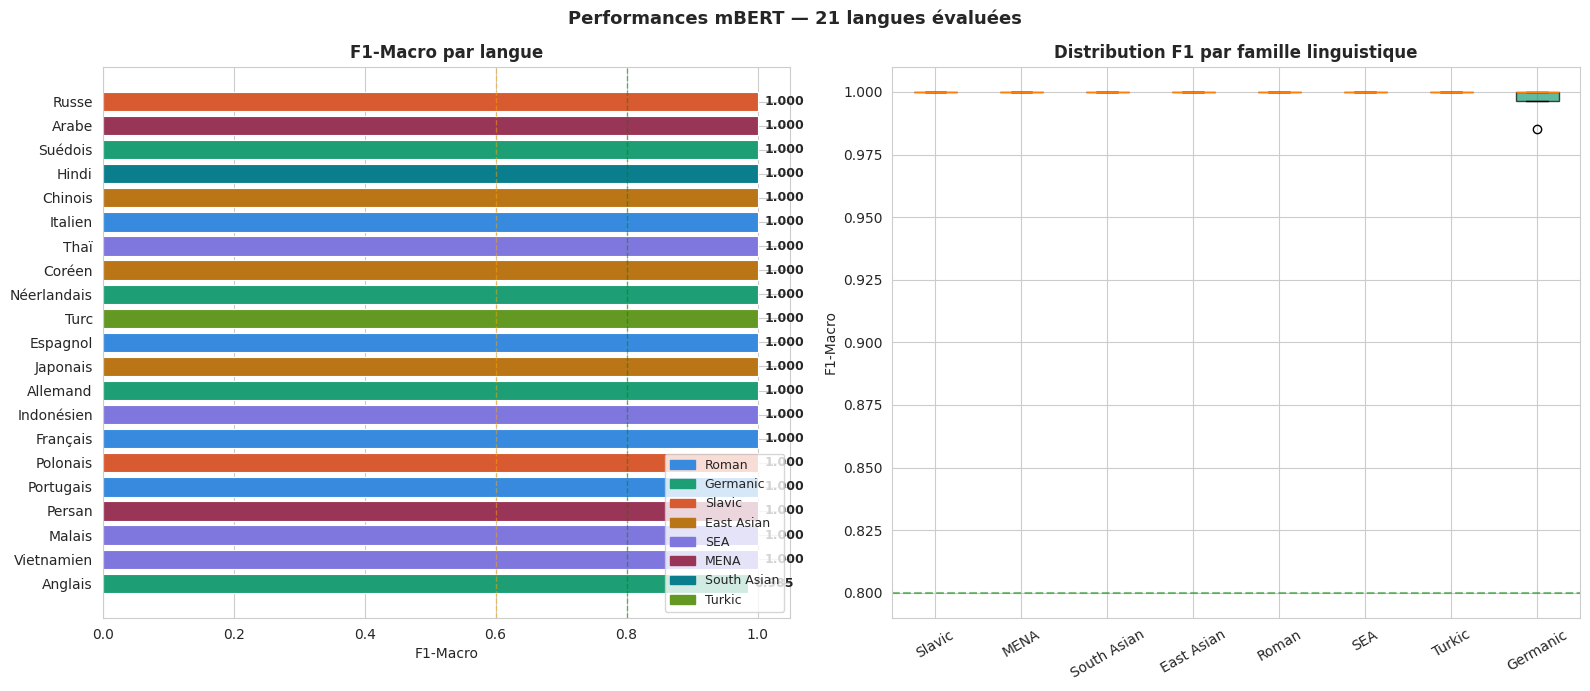


Analyse des tendances par famille linguistique :
  Slavic          → F1 moy=1.000  min=1.000  max=1.000
  MENA            → F1 moy=1.000  min=1.000  max=1.000
  South Asian     → F1 moy=1.000  min=1.000  max=1.000
  East Asian      → F1 moy=1.000  min=1.000  max=1.000
  Roman           → F1 moy=1.000  min=1.000  max=1.000
  SEA             → F1 moy=1.000  min=1.000  max=1.000
  Turkic          → F1 moy=1.000  min=1.000  max=1.000
  Germanic        → F1 moy=0.996  min=0.985  max=1.000


In [16]:
# ── Graphique F1 par langue (heatmap + barplot) ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Barplot F1 par langue, coloré par groupe
GROUP_COLORS = {
    'Roman':      '#378ADD',
    'Germanic':   '#1D9E75',
    'Slavic':     '#D85A30',
    'East Asian': '#BA7517',
    'SEA':        '#7F77DD',
    'MENA':       '#993556',
    'South Asian':'#0A7E8C',
    'Turkic':     '#639922',
}

sorted_langs = sorted(lang_results.items(), key=lambda x: -x[1]['f1'])
names   = [l for l,_ in sorted_langs]
f1s     = [r['f1'] for _,r in sorted_langs]
groups  = [r['group'] for _,r in sorted_langs]
colors  = [GROUP_COLORS.get(g, '#888') for g in groups]

bars = axes[0].barh(names[::-1], f1s[::-1], color=colors[::-1],
                    edgecolor='white', linewidth=0.8)
axes[0].set_xlim(0, 1.05)
axes[0].axvline(x=0.8,  color='green',  linestyle='--', alpha=0.5, linewidth=1)
axes[0].axvline(x=0.6,  color='orange', linestyle='--', alpha=0.5, linewidth=1)
axes[0].set_title('F1-Macro par langue', fontweight='bold')
axes[0].set_xlabel('F1-Macro')
for bar, val in zip(bars, f1s[::-1]):
    axes[0].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9, fontweight='bold')

# Légende groupes
from matplotlib.patches import Patch
legend_patches = [Patch(color=c, label=g) for g,c in GROUP_COLORS.items() if g in set(groups)]
axes[0].legend(handles=legend_patches, loc='lower right', fontsize=9)

# Boxplot F1 par groupe linguistique
group_f1s = defaultdict(list)
for lang, res in lang_results.items():
    group_f1s[res['group']].append(res['f1'])

sorted_groups = sorted(group_f1s.items(), key=lambda x: -np.mean(x[1]))
bp_data   = [v for _,v in sorted_groups]
bp_labels = [g for g,_ in sorted_groups]
bp_colors = [GROUP_COLORS.get(g,'#888') for g,_ in sorted_groups]

bp = axes[1].boxplot(bp_data, labels=bp_labels, patch_artist=True, notch=False)
for patch, color in zip(bp['boxes'], bp_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].axhline(y=0.8, color='green', linestyle='--', alpha=0.5)
axes[1].set_title('Distribution F1 par famille linguistique', fontweight='bold')
axes[1].set_ylabel('F1-Macro')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle(f'Performances mBERT — {len(lang_results)} langues évaluées',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('data/04b_performance_by_lang.png', dpi=150, bbox_inches='tight')
plt.show()

# Analyse des tendances
print('\nAnalyse des tendances par famille linguistique :')
for group, vals in sorted(group_f1s.items(), key=lambda x: -np.mean(x[1])):
    print(f'  {group:15s} → F1 moy={np.mean(vals):.3f}  min={min(vals):.3f}  max={max(vals):.3f}')

## 7. Détection sur emails réels multilingues

In [17]:
@torch.no_grad()
def predict(text, model, tokenizer):
    model.eval()
    enc   = tokenizer(str(text)[:3000], max_length=MAX_LENGTH,
                      padding='max_length', truncation=True, return_tensors='pt')
    out   = model(input_ids=enc['input_ids'].to(DEVICE),
                  attention_mask=enc['attention_mask'].to(DEVICE))
    probs = torch.softmax(out.logits, -1).cpu().numpy()[0]
    pred  = probs.argmax()
    return {'prediction': CLASS_NAMES[pred], 'confidence': float(probs[pred]),
            'probs': {c: float(p) for c,p in zip(CLASS_NAMES, probs)}}


# Même email de phishing traduit en 10 langues
PHISHING_MULTI = [
    ('EN', 'Your account has been suspended. Verify immediately: http://paypa1-secure.xyz/login'),
    ('FR', 'Votre compte a été suspendu. Vérifiez immédiatement : http://paypa1-securite.xyz/connexion'),
    ('AR', 'تم تعليق حسابك. تحقق على الفور: http://paypa1-secure.xyz/login'),
    ('ZH', '您的账户已被暂停。请立即验证：http://paypa1-secure.xyz/login'),
    ('RU', 'Ваш аккаунт был заблокирован. Проверьте немедленно: http://paypa1-secure.xyz/login'),
    ('ES', 'Su cuenta ha sido suspendida. Verifique inmediatamente: http://paypa1-secure.xyz/login'),
    ('HI', 'आपका खाता निलंबित कर दिया गया है। तुरंत सत्यापित करें: http://paypa1-secure.xyz/login'),
    ('DE', 'Ihr Konto wurde gesperrt. Überprüfen Sie sofort: http://paypa1-secure.xyz/login'),
    ('PT', 'Sua conta foi suspensa. Verifique imediatamente: http://paypa1-secure.xyz/login'),
    ('TR', 'Hesabınız askıya alındı. Hemen doğrulayın: http://paypa1-secure.xyz/login'),
]

print('Détection du MÊME email de phishing en 10 langues')
print('=' * 65)
print('(URL suspecte paypa1-secure.xyz commune à tous)\n')

results = []
for lang, text in PHISHING_MULTI:
    r = predict(text, best_model, tokenizer)
    detected = r['prediction'] == 'phishing'
    sign = '✓' if detected else '✗'
    results.append({'lang': lang, 'detected': detected, 'conf': r['confidence'], 'pred': r['prediction']})
    print(f'  [{sign}][{lang}] Prédit:{r["prediction"].upper():10s} Conf:{r["confidence"]:.1%}  '
          f'→ ham:{r["probs"]["ham"]:.2f} spam:{r["probs"]["spam"]:.2f} phishing:{r["probs"]["phishing"]:.2f}')

detect_rate = sum(r['detected'] for r in results) / len(results)
print(f'\nTaux de détection : {sum(r["detected"] for r in results)}/{len(results)} ({detect_rate:.0%})')

Détection du MÊME email de phishing en 10 langues
(URL suspecte paypa1-secure.xyz commune à tous)

  [✓][EN] Prédit:PHISHING   Conf:100.0%  → ham:0.00 spam:0.00 phishing:1.00
  [✓][FR] Prédit:PHISHING   Conf:100.0%  → ham:0.00 spam:0.00 phishing:1.00
  [✓][AR] Prédit:PHISHING   Conf:100.0%  → ham:0.00 spam:0.00 phishing:1.00
  [✓][ZH] Prédit:PHISHING   Conf:100.0%  → ham:0.00 spam:0.00 phishing:1.00
  [✓][RU] Prédit:PHISHING   Conf:100.0%  → ham:0.00 spam:0.00 phishing:1.00
  [✓][ES] Prédit:PHISHING   Conf:100.0%  → ham:0.00 spam:0.00 phishing:1.00
  [✓][HI] Prédit:PHISHING   Conf:100.0%  → ham:0.00 spam:0.00 phishing:1.00
  [✓][DE] Prédit:PHISHING   Conf:100.0%  → ham:0.00 spam:0.00 phishing:1.00
  [✓][PT] Prédit:PHISHING   Conf:100.0%  → ham:0.00 spam:0.00 phishing:1.00
  [✓][TR] Prédit:PHISHING   Conf:100.0%  → ham:0.00 spam:0.00 phishing:1.00

Taux de détection : 10/10 (100%)


## 8. Rapport final & sauvegarde

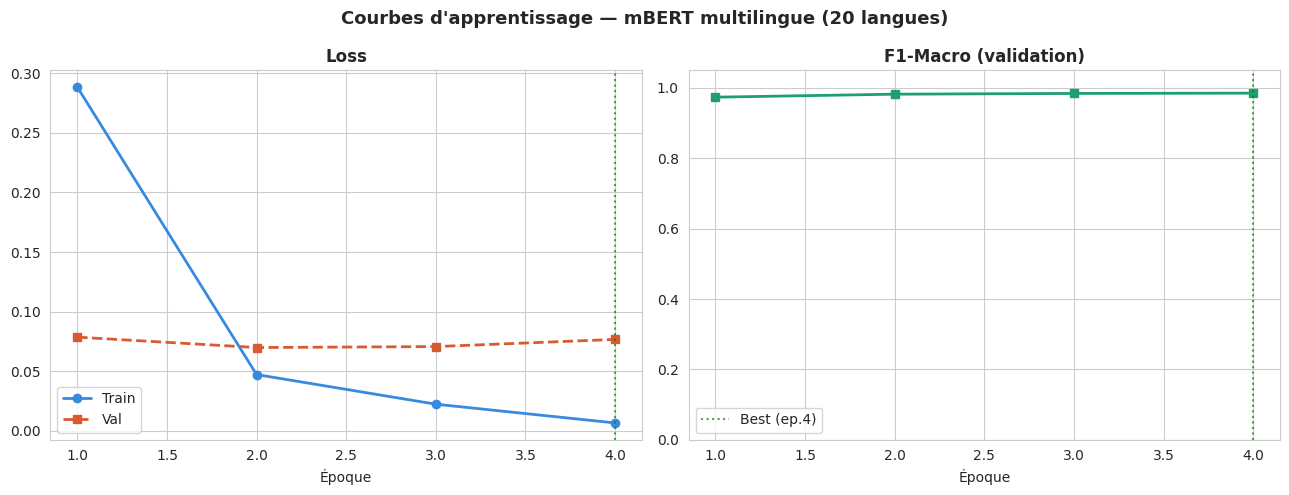

Résultats sauvegardés.

RÉSUMÉ FINAL :
  Modèle          : distilbert-base-multilingual-cased
  Langues         : 20 langues entraînées
  Dataset total   : 23,446 emails
  F1 global       : 0.9867
  Phishing multilingue détecté : 100% des langues testées
  Meilleure langue  : Russe (F1=1.000)
  Langue difficile  : Anglais (F1=0.985)

Pour utiliser ce modèle dans le pipeline hybride (NB 05) :
  Changer DATA_DIR / "distilbert_model" → DATA_DIR / "multilingual_model"


In [18]:
# Courbes d'apprentissage
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ep = range(1, len(history['train_loss'])+1)

axes[0].plot(ep, history['train_loss'], 'o-', color='#378ADD', label='Train', lw=2)
axes[0].plot(ep, history['val_loss'],   's--', color='#D85A30', label='Val',   lw=2)
axes[0].set_title('Loss', fontweight='bold')
axes[0].set_xlabel('Époque')
axes[0].legend()
axes[0].axvline(x=best_epoch, color='green', linestyle=':', alpha=0.7)

axes[1].plot(ep, history['val_f1'], 's-', color='#1D9E75', lw=2, marker='s')
axes[1].set_title('F1-Macro (validation)', fontweight='bold')
axes[1].set_xlabel('Époque')
axes[1].set_ylim(0, 1.05)
axes[1].axvline(x=best_epoch, color='green', linestyle=':', alpha=0.7, label=f'Best (ep.{best_epoch})')
axes[1].legend()

plt.suptitle('Courbes d\'apprentissage — mBERT multilingue (20 langues)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('data/04b_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Sauvegarde JSON
results_04b = {
    'model':            MULTILINGUAL_MODEL,
    'languages_trained': len(TARGET_LANGUAGES),
    'fast_mode':        FAST_MODE,
    'total_emails':     len(df_all),
    'best_epoch':       best_epoch,
    'best_val_f1':      round(best_f1, 4),
    'test_f1_macro':    round(test_f1, 4),
    'test_accuracy':    round(test_acc, 4),
    'phishing_detection_multilang': round(detect_rate, 4),
    'by_language': {
        lang: {'f1': round(r['f1'],4), 'acc': round(r['acc'],4),
               'n': r['n'], 'group': r['group']}
        for lang, r in lang_results.items()
    },
    'history': {k: [round(v,4) for v in vals] for k,vals in history.items()},
}

with open(DATA_DIR / '04b_results.json', 'w', encoding='utf-8') as f:
    json.dump(results_04b, f, indent=2, ensure_ascii=False)

print('Résultats sauvegardés.')
print(f'\nRÉSUMÉ FINAL :')
print(f'  Modèle          : {MULTILINGUAL_MODEL}')
print(f'  Langues         : {len(TARGET_LANGUAGES)} langues entraînées')
print(f'  Dataset total   : {len(df_all):,} emails')
print(f'  F1 global       : {test_f1:.4f}')
print(f'  Phishing multilingue détecté : {detect_rate:.0%} des langues testées')

if lang_results:
    best_lang  = max(lang_results, key=lambda l: lang_results[l]['f1'])
    worst_lang = min(lang_results, key=lambda l: lang_results[l]['f1'])
    print(f'  Meilleure langue  : {best_lang} (F1={lang_results[best_lang]["f1"]:.3f})')
    print(f'  Langue difficile  : {worst_lang} (F1={lang_results[worst_lang]["f1"]:.3f})')

print()
print('Pour utiliser ce modèle dans le pipeline hybride (NB 05) :')
print('  Changer DATA_DIR / "distilbert_model" → DATA_DIR / "multilingual_model"')